# 01 Analyse Exploratoire des Données (EDA)

## Contexte
Ce notebook constitue la première étape du projet **Telemed Urgence IA**.  
Il explore le dataset de télémédecine afin de comprendre les données disponibles avant toute modélisation.

## Objectifs
- Comprendre la distribution des variables et de la variable cible
- Identifier les valeurs manquantes et les outliers
- Analyser le déséquilibre des classes (problème métier critique)
- Explorer le contenu textuel des descriptions de symptômes
- Formuler les actions à entreprendre pour le prétraitement

## Dataset
- **10 080 échantillons** × 13 variables
- **Variable cible** : `niveau_urgence`
  - `0` → Non urgent
  - `1` → Urgence relative  
  - `2` → Urgence vitale

## 1. Imports et configuration

In [16]:
# 01 EDA : Analyse Exploratoire des Données
# Projet: Telemed Urgence IA

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Style global
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

print("Imports OK")

Imports OK


## 2. Chargement des données

In [17]:
# 02 Chargement des données

df = pd.read_csv("../data/raw/dataset_telemed.csv")

print(f"Dataset chargé : {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f"\nColonnes : {list(df.columns)}")
print(f"\nDistribution cible :")
print(df['niveau_urgence'].value_counts())
print(f"\nAperçu :")
df.head()

Dataset chargé : 10080 lignes × 13 colonnes

Colonnes : ['patient_id', 'sexe', 'age', 'zone_vie', 'source', 'freq_cardiaque', 'tension_sys', 'temp', 'sat_oxygene', 'antecedents', 'duree_symptomes', 'description_symptomes', 'niveau_urgence']

Distribution cible :
niveau_urgence
0    5053
1    3551
2    1476
Name: count, dtype: int64

Aperçu :


,patient_id,sexe,age,zone_vie,source,freq_cardiaque,tension_sys,temp,sat_oxygene,antecedents,duree_symptomes,description_symptomes,niveau_urgence
0,P0001,H,19.0,R,appel,110.4,128.6,37.8,93.8,0.0,62.2,Douleur abdominale aiguë localisée dans le qua...,1
1,P0002,H,56.0,U,appel,72.0,153.5,36.0,100.0,1.0,45.8,Demande de certificat médical pour une activit...,0
2,P0003,H,1.0,U,appel,70.4,117.7,36.9,97.6,0.0,8.0,Douleur dorsale chronique sans aggravation réc...,0
3,P0004,H,7.0,R,appel,84.7,126.3,37.1,96.1,1.0,28.5,Besoin d'un avis suite à une fin de traitement...,0
4,P0005,F,28.0,R,appel,114.3,168.1,38.6,95.1,0.0,54.6,Vomissements répétés et incapacité totale à s'...,1


## 3. Types et valeurs manquantes

On vérifie les types de chaque colonne et l'absence éventuelle de valeurs manquantes.  
Des valeurs manquantes sur les constantes vitales nécessiteraient une imputation avant modélisation

In [18]:
# 03 Types, valeurs manquantes

print("Types de données :")
print(df.dtypes)

print(f"\n Valeurs manquantes :")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Manquants': missing,
    '% Manquants': missing_pct
}).query('Manquants > 0').sort_values('% Manquants', ascending=False)

print(missing_df)
print(f"\nTotal lignes sans aucun NaN : {df.dropna().shape[0]}")

Types de données :
patient_id                object
sexe                      object
age                      float64
zone_vie                  object
source                    object
freq_cardiaque           float64
tension_sys              float64
temp                     float64
sat_oxygene              float64
antecedents              float64
duree_symptomes          float64
description_symptomes     object
niveau_urgence             int64
dtype: object

 Valeurs manquantes :
                       Manquants  % Manquants
freq_cardiaque                25         0.25
sexe                          22         0.22
source                        18         0.18
age                           17         0.17
zone_vie                      17         0.17
tension_sys                   17         0.17
temp                          17         0.17
description_symptomes         17         0.17
antecedents                   15         0.15
duree_symptomes               13         0.13
sat_oxyge

## 4. Distribution de la variable cible

> **Point critique** : La classe 2 (urgence vitale) est largement sous-représentée.  
> Cela implique d'utiliser `class_weight='balanced'` lors de l'entraînement et de prioriser le **Recall de la classe 2** comme métrique principale.

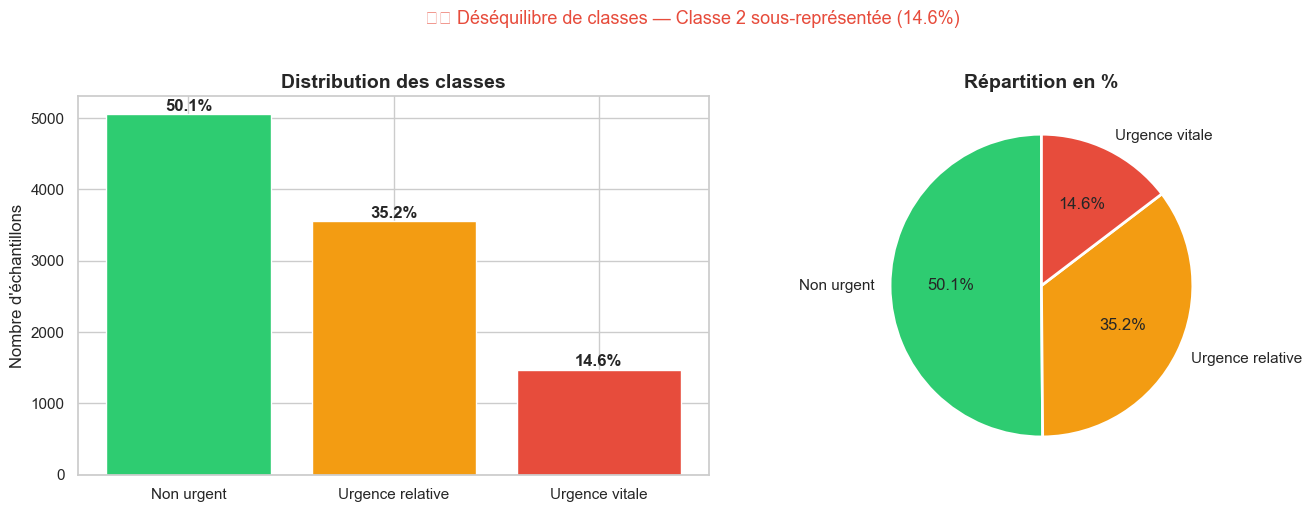


Détail :
  Classe 0 (Non urgent) : 5053 échantillons (50.1%)
  Classe 1 (Urgence relative) : 3551 échantillons (35.2%)
  Classe 2 (Urgence vitale) : 1476 échantillons (14.6%)


In [19]:
# 04 Distribution de la variable cible

labels = {0: 'Non urgent', 1: 'Urgence relative', 2: 'Urgence vitale'}
colors = ['#2ecc71', '#f39c12', '#e74c3c']

counts = df['niveau_urgence'].value_counts().sort_index()
pcts = (counts / len(df) * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
bars = axes[0].bar(
    [labels[i] for i in counts.index],
    counts.values,
    color=colors
)
axes[0].set_title("Distribution des classes", fontsize=14, fontweight='bold')
axes[0].set_ylabel("Nombre d'échantillons")
for bar, pct in zip(bars, pcts):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 50,
                 f'{pct}%', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=[labels[i] for i in counts.index],
            colors=colors, autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title("Répartition en %", fontsize=14, fontweight='bold')

plt.suptitle("⚠️ Déséquilibre de classes — Classe 2 sous-représentée (14.6%)",
             fontsize=13, color='#e74c3c', y=1.02)
plt.tight_layout()
plt.show()

print(f"\nDétail :")
for i, (count, pct) in enumerate(zip(counts, pcts)):
    print(f"  Classe {i} ({labels[i]}) : {count} échantillons ({pct}%)")

## 5. Statistiques descriptives

Analyse des variables numériques : age, constantes vitales et durée des symptômes.

In [20]:
# 05 - Statistiques descriptives variables numériques
num_cols = ['age', 'freq_cardiaque', 'tension_sys', 'temp', 
            'sat_oxygene', 'duree_symptomes']

print("Statistiques descriptives :")
df[num_cols].describe().round(2)

Statistiques descriptives :


,age,freq_cardiaque,tension_sys,temp,sat_oxygene,duree_symptomes
count,10063.00,10055.00,10063.00,10063.00,10070.00,10067.00
mean,47.48,91.97,142.63,37.71,94.77,36.68
std,27.63,22.72,25.94,1.16,4.59,20.62
min,0.00,45.00,80.00,35.50,75.00,0.50
25%,24.00,75.40,124.85,36.90,92.70,18.80
50%,48.00,88.10,136.80,37.40,96.20,37.10
75%,71.00,105.20,155.60,38.40,97.90,54.50
max,95.00,190.00,230.00,41.50,100.00,72.00


## 6. Distribution des variables numériques par classe

On visualise comment chaque variable numérique se distribue selon le niveau d'urgence.  
Des distributions bien séparées indiquent un fort pouvoir discriminant.

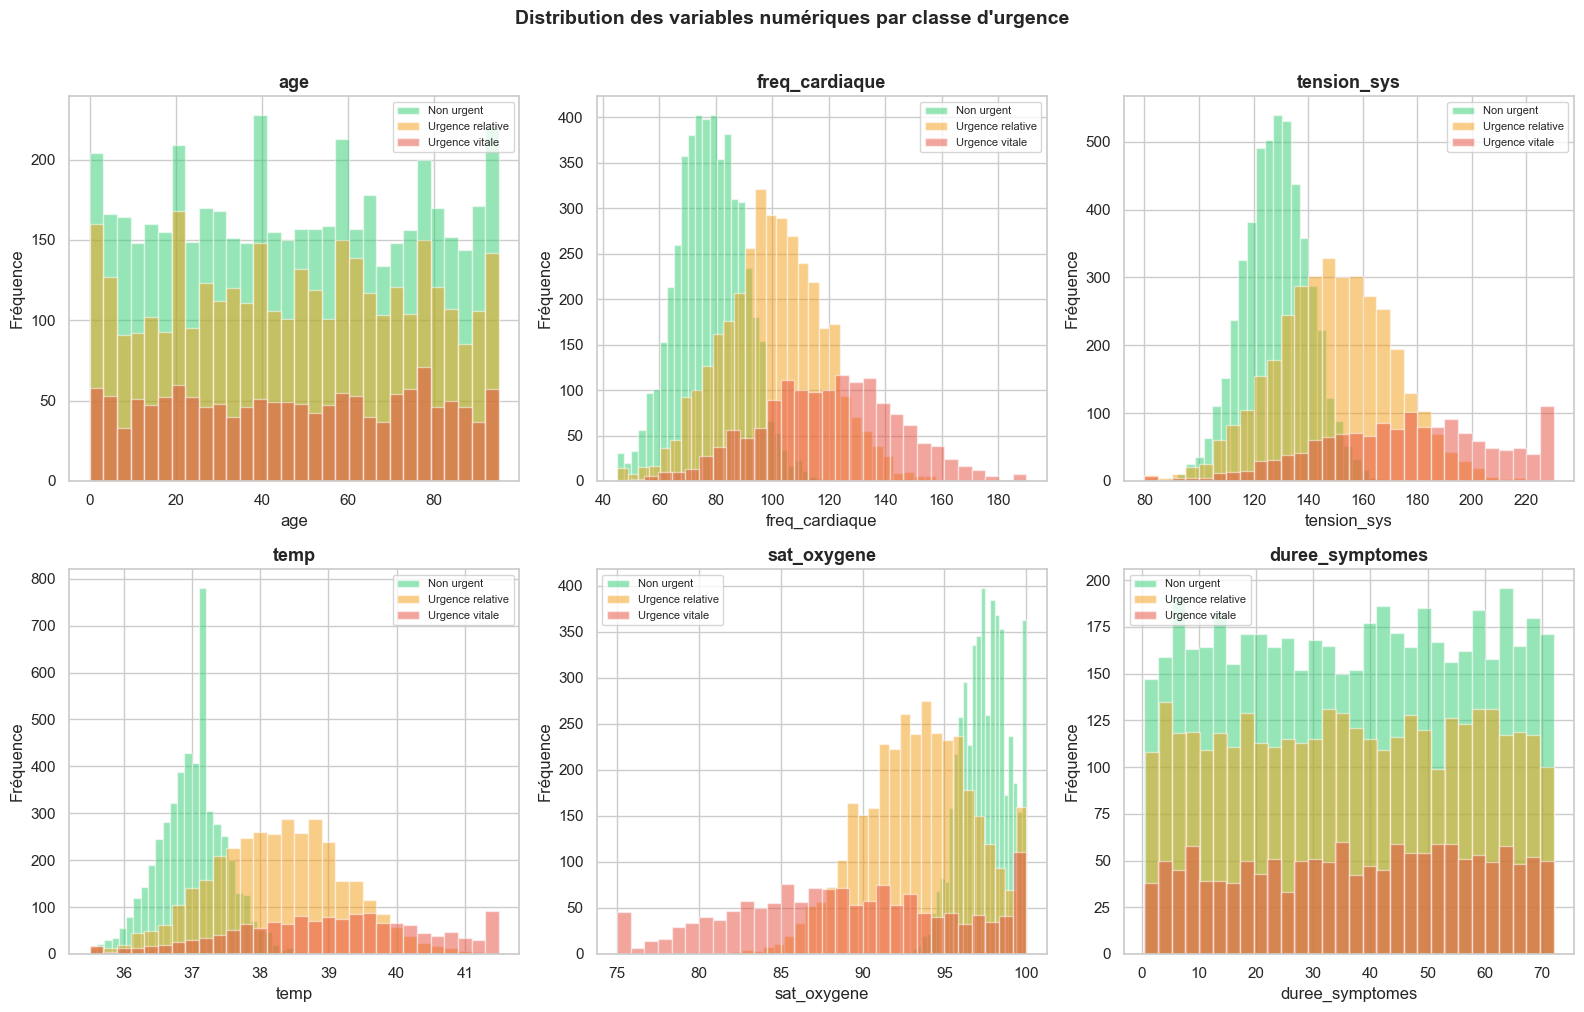

In [21]:
# 06 Distribution des variables numériques par classe

num_cols = ['age', 'freq_cardiaque', 'tension_sys', 'temp', 
            'sat_oxygene', 'duree_symptomes']

colors = {0: '#2ecc71', 1: '#f39c12', 2: '#e74c3c'}
labels = {0: 'Non urgent', 1: 'Urgence relative', 2: 'Urgence vitale'}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    for classe in [0, 1, 2]:
        subset = df[df['niveau_urgence'] == classe][col].dropna()
        axes[i].hist(subset, bins=30, alpha=0.5,
                     color=colors[classe], label=labels[classe])
    axes[i].set_title(col, fontsize=13, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Fréquence")
    axes[i].legend(fontsize=8)

plt.suptitle("Distribution des variables numériques par classe d'urgence",
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 7. Boxplots — Détection des outliers

Les boxplots permettent d'identifier les valeurs extrêmes.  
Dans un contexte médical, certains outliers sont cliniquement cohérents (ex: FC=190 pour une urgence vitale) et ne doivent pas être supprimés.

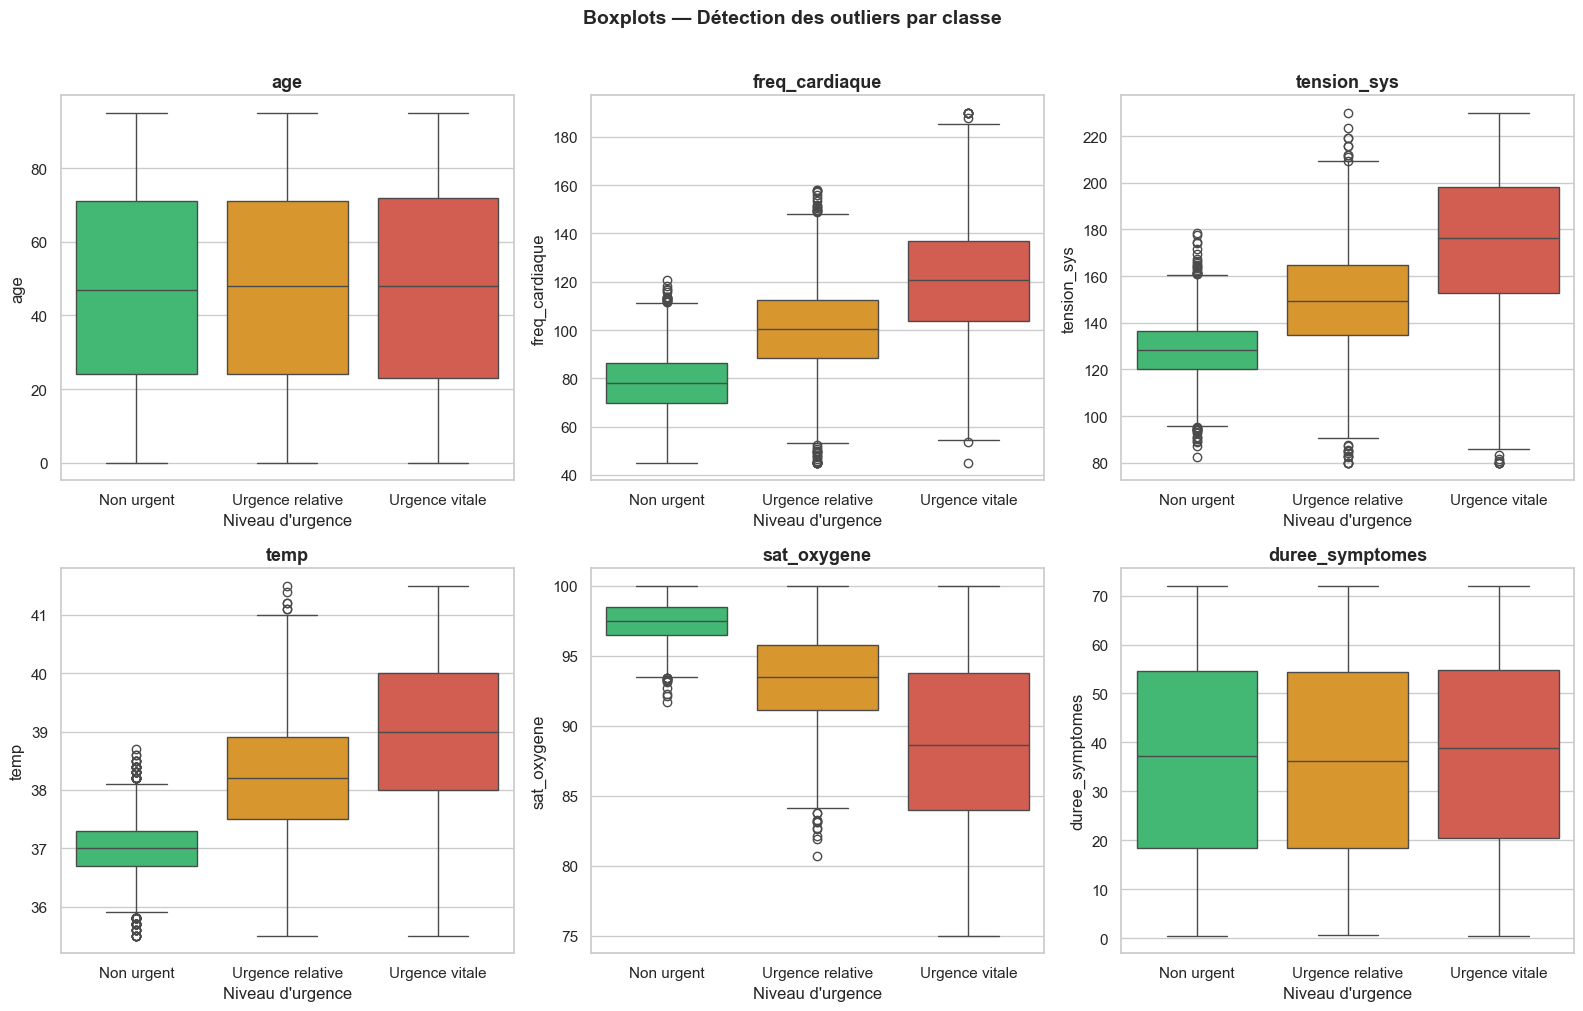

In [22]:
# 07 Boxplots par classe (détection outliers)

num_cols = ['age', 'freq_cardiaque', 'tension_sys', 'temp', 
            'sat_oxygene', 'duree_symptomes']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

palette = ['#2ecc71', '#f39c12', '#e74c3c']

for i, col in enumerate(num_cols):
    sns.boxplot(
        data=df,
        x='niveau_urgence',
        y=col,
        palette=palette,
        ax=axes[i]
    )
    axes[i].set_title(col, fontsize=13, fontweight='bold')
    axes[i].set_xlabel("Niveau d'urgence")
    axes[i].set_xticklabels(['Non urgent', 'Urgence relative', 'Urgence vitale'])

plt.suptitle("Boxplots — Détection des outliers par classe",
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 8. Matrice de corrélation

On analyse les corrélations entre variables numériques et avec la variable cible.  
Les variables les plus corrélées avec `niveau_urgence` seront les plus discriminantes pour les modèles.

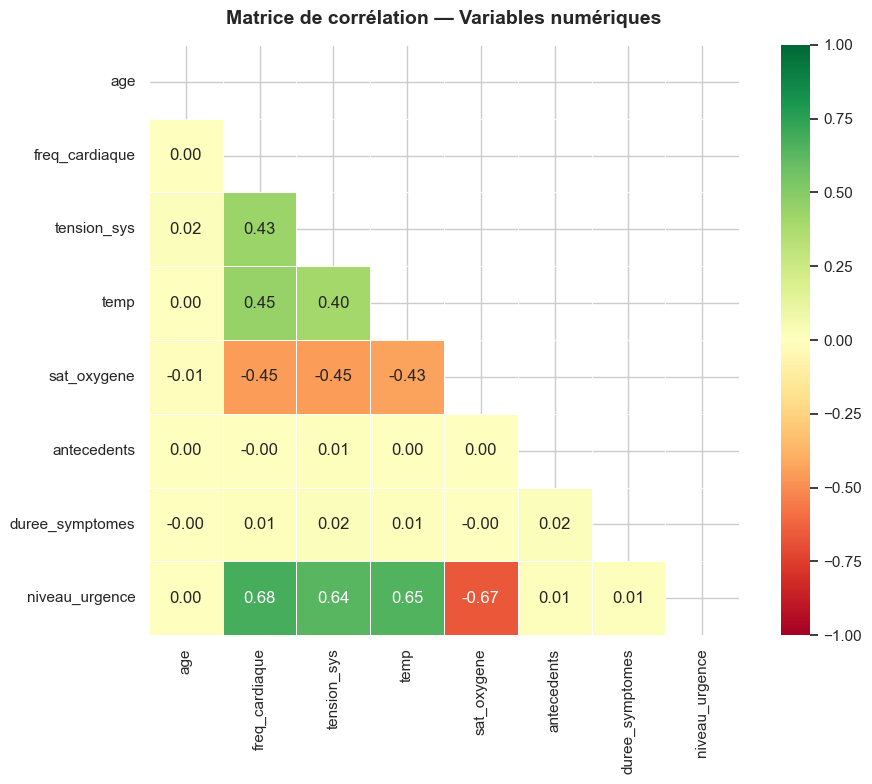


Corrélations avec niveau_urgence (triées) :
freq_cardiaque     0.68
sat_oxygene       -0.67
temp               0.65
tension_sys        0.64
antecedents        0.01
duree_symptomes    0.01
age                0.00
Name: niveau_urgence, dtype: float64


In [23]:
# 08 heatmap des corrélations
num_cols = ['age', 'freq_cardiaque', 'tension_sys', 'temp', 
            'sat_oxygene', 'antecedents', 'duree_symptomes', 'niveau_urgence']

corr = df[num_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax
)

ax.set_title("Matrice de corrélation — Variables numériques",
             fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# corrélations avec la cible
print("\nCorrélations avec niveau_urgence (triées) :")
print(corr['niveau_urgence'].drop('niveau_urgence').sort_values(key=abs, ascending=False))

## 9. Variables catégorielles vs niveau d'urgence

Analyse de l'impact des variables catégorielles (`sexe`, `zone_vie`, `source`) sur le niveau d'urgence.  
> **Note éthique** : `sexe` et `zone_vie` sont des variables potentiellement discriminantes — elles seront retirées dans le Scénario 2 (conformité RGPD).

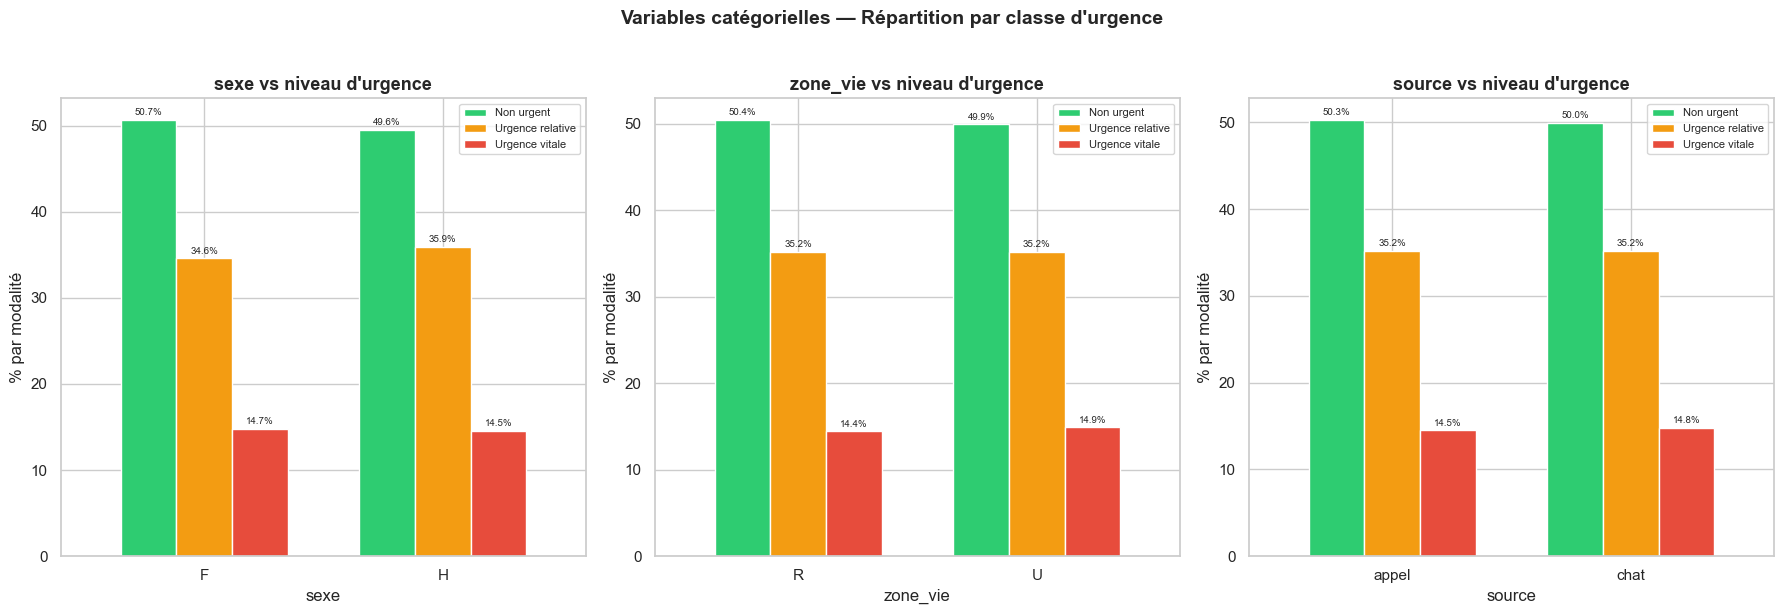

In [24]:
# 09 vars catégorielles vs niveau d'urgence

cat_cols = ['sexe', 'zone_vie', 'source']
labels = {0: 'Non urgent', 1: 'Urgence relative', 2: 'Urgence vitale'}
colors = ['#2ecc71', '#f39c12', '#e74c3c']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, col in enumerate(cat_cols):
    ct = pd.crosstab(df[col], df['niveau_urgence'], normalize='index') * 100
    ct.columns = [labels[c] for c in ct.columns]
    ct.plot(kind='bar', ax=axes[i], color=colors, edgecolor='white', width=0.7)
    axes[i].set_title(f"{col} vs niveau d'urgence", fontsize=13, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("% par modalité")
    axes[i].legend(fontsize=8)
    axes[i].tick_params(axis='x', rotation=0)
    for container in axes[i].containers:
        axes[i].bar_label(container, fmt='%.1f%%', fontsize=7, padding=2)

plt.suptitle("Variables catégorielles — Répartition par classe d'urgence",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 10. Analyse textuelle — description_symptomes

La variable `description_symptomes` est un texte libre rédigé par le patient.  
On utilise **spaCy** (modèle français `fr_core_news_sm`) pour :
- **Lemmatiser** les mots (ramener à leur forme de base)
- **Supprimer les stopwords** (mots inutiles : le, la, de, et...)
- Analyser la fréquence des termes discriminants par classe

> Cette étape est la base du pipeline NLP qui sera utilisé dans le prétraitement.

Nettoyage du texte en cours...
Texte nettoyé !


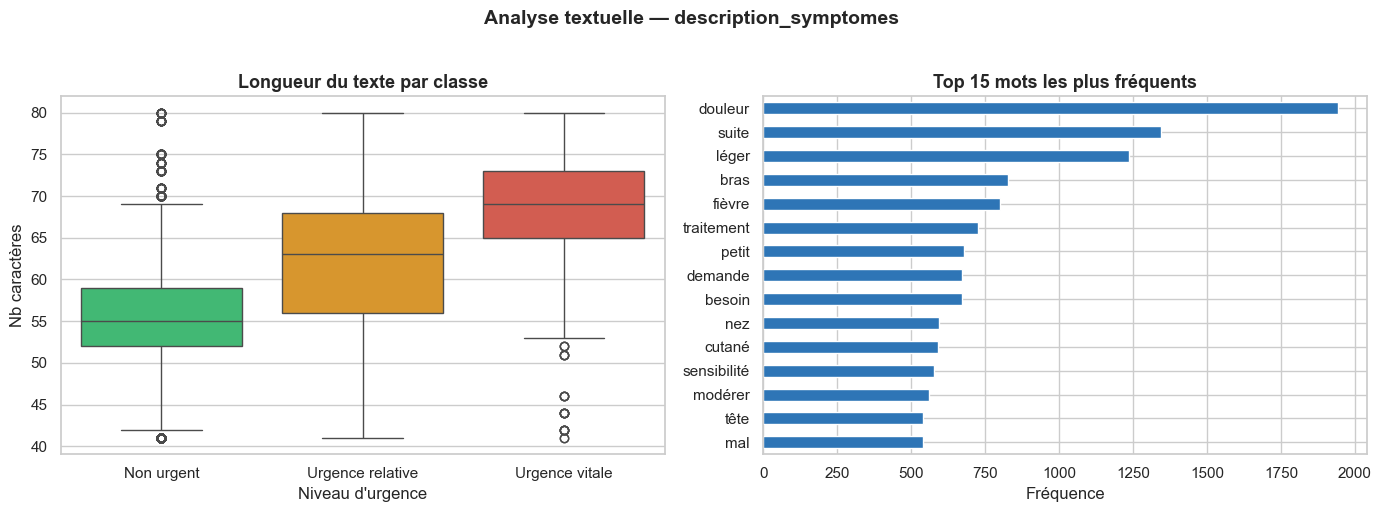

In [25]:
# 10 analyse du texte (description_symptomes)
import spacy
from sklearn.feature_extraction.text import CountVectorizer

nlp = spacy.load("fr_core_news_sm")

# nettoyage basique
def clean_text(text):
    if pd.isna(text):
        return ""
    doc = nlp(text.lower())
    tokens = [token.lemma_ for token in doc 
              if not token.is_stop and not token.is_punct and len(token.text) > 2]
    return " ".join(tokens)

print("Nettoyage du texte en cours...")
df['text_clean'] = df['description_symptomes'].apply(clean_text)
print("Texte nettoyé !")

# longeur des descriptions par classe
df['text_len'] = df['description_symptomes'].str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# distribution longueur
sns.boxplot(data=df, x='niveau_urgence', y='text_len',
            palette=['#2ecc71', '#f39c12', '#e74c3c'], ax=axes[0])
axes[0].set_title("Longueur du texte par classe", fontsize=13, fontweight='bold')
axes[0].set_xticklabels(['Non urgent', 'Urgence relative', 'Urgence vitale'])
axes[0].set_xlabel("Niveau d'urgence")
axes[0].set_ylabel("Nb caractères")

# Mots les plus fréquents global
vectorizer = CountVectorizer(max_features=15)
X = vectorizer.fit_transform(df['text_clean'].dropna())
word_freq = pd.Series(
    X.toarray().sum(axis=0),
    index=vectorizer.get_feature_names_out()
).sort_values(ascending=True)

word_freq.plot(kind='barh', ax=axes[1], color='#2E75B6')
axes[1].set_title("Top 15 mots les plus fréquents", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Fréquence")

plt.suptitle("Analyse textuelle — description_symptomes",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 11. Top mots par classe d'urgence

On identifie les mots les plus fréquents dans chaque classe.  
Un vocabulaire clairement distinct entre les classes valide l'intérêt du NLP pour la prédiction.

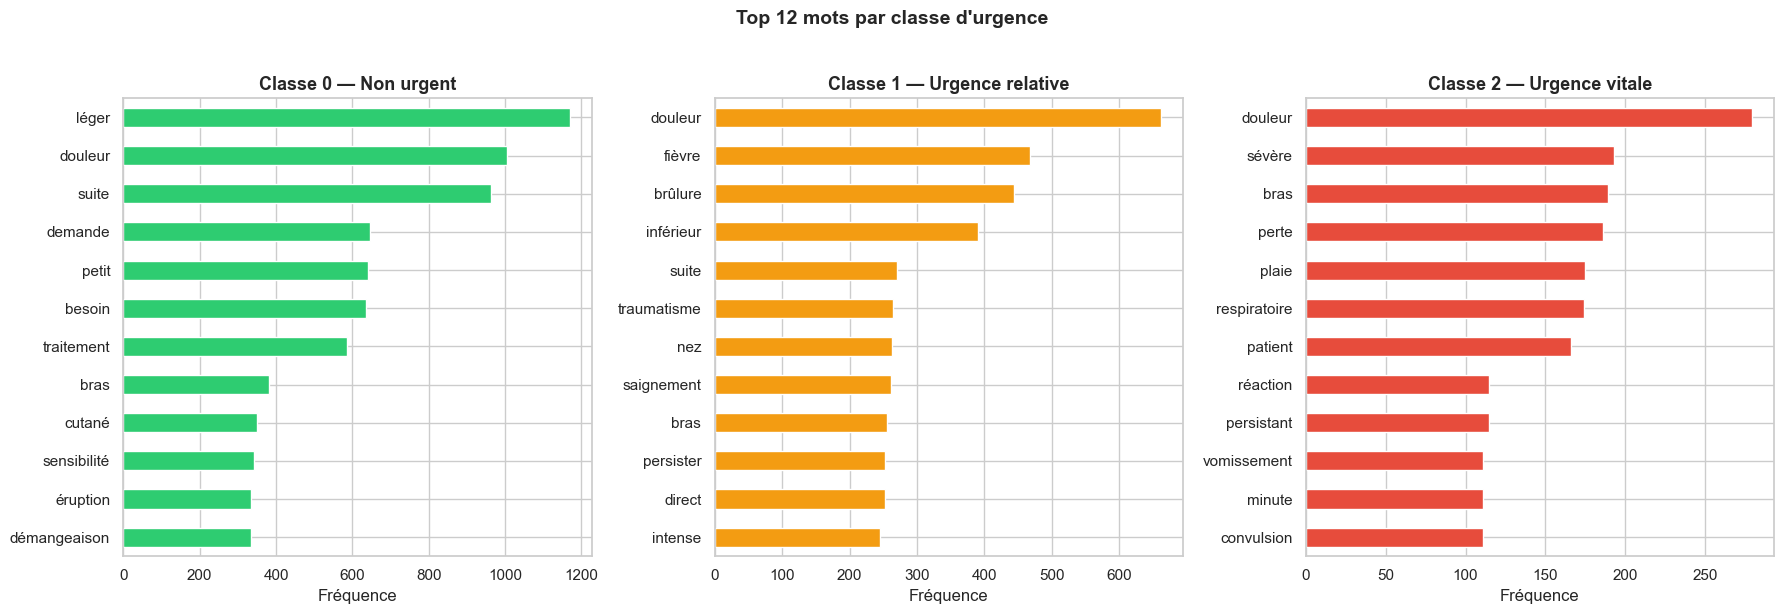

In [26]:
# 11 Top mots par classe d'urgence

labels = {0: 'Non urgent', 1: 'Urgence relative', 2: 'Urgence vitale'}
colors = ['#2ecc71', '#f39c12', '#e74c3c']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for classe in [0, 1, 2]:
    
    # on filtre les textes nettoyés (cellule 10) pour la classe courante
    texts = df[df['niveau_urgence'] == classe]['text_clean'].dropna()
    
    # CountVectorizer compte combien de fois chaque mot apparaît
    # max_features=12 => on garde uniquement les 12 mots les plus fréquents
    vectorizer = CountVectorizer(max_features=12)
    
    # fit_transform : apprend le vocabulaire ET transforme les textes
    # en matrice numérique (une ligne par texte, une colonne par mot)
    X = vectorizer.fit_transform(texts)
    
    # on somme les colonnes => fréquence totale de chaque mot dans la classe
    # get_feature_names_out() => récupère les noms des mots correspondants
    word_freq = pd.Series(
        X.toarray().sum(axis=0),
        index=vectorizer.get_feature_names_out()
    ).sort_values(ascending=True)  # tri croissant pour barh (plus grand en haut)
    
    # visualisation horizontale pour lisibilité des mots
    word_freq.plot(kind='barh', ax=axes[classe], color=colors[classe])
    axes[classe].set_title(f"Classe {classe} — {labels[classe]}",
                           fontsize=13, fontweight='bold')
    axes[classe].set_xlabel("Fréquence")

plt.suptitle("Top 12 mots par classe d'urgence",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 12. Détection des doublons

Avant de conclure l'EDA, on vérifie la présence de doublons complets dans le dataset, un point souvent oublié mais qui peut fausser l'évaluation des modèles s'il y a fuite entre train et test

In [27]:
# Détection des doublons complets
n_duplicates = df.duplicated().sum()
pct_duplicates = n_duplicates / len(df) * 100

print(f"Doublons complets détectés : {n_duplicates} ({pct_duplicates:.2f}% du dataset)")

if n_duplicates > 0:
    print(f"\nAperçu des doublons :")
    display(df[df.duplicated(keep=False)].sort_values(by=list(df.columns)).head(10))
    print(f"\nDécision : on garde ces doublons en l'état car le split train/test est")
    print(f"   stratifié par random_state fixe — un doublon a la même probabilité")
    print(f"   d'être dans le train ou le test qu'un échantillon unique. À surveiller")
    print(f"   si le taux dépassait 5% du dataset (ici largement sous ce seuil).")
else:
    print("Aucun doublon détecté.")

Doublons complets détectés : 77 (0.76% du dataset)

Aperçu des doublons :


,patient_id,sexe,age,zone_vie,source,freq_cardiaque,tension_sys,temp,sat_oxygene,antecedents,duree_symptomes,description_symptomes,niveau_urgence,text_clean,text_len
35,P0036,H,73.0,R,appel,85.7,179.7,38.0,99.1,1.0,15.9,Traumatisme direct sur le nez avec saignement ...,1,traumatisme direct nez saignement persister,57.0
10041,P0036,H,73.0,R,appel,85.7,179.7,38.0,99.1,1.0,15.9,Traumatisme direct sur le nez avec saignement ...,1,traumatisme direct nez saignement persister,57.0
39,P0040,F,94.0,U,chat,156.5,205.4,40.4,83.6,0.0,64.5,Réaction anaphylactique avec gonflement du vis...,2,réaction anaphylactique gonflement visage gorge,65.0
10045,P0040,F,94.0,U,chat,156.5,205.4,40.4,83.6,0.0,64.5,Réaction anaphylactique avec gonflement du vis...,2,réaction anaphylactique gonflement visage gorge,65.0
107,P0108,H,20.0,R,appel,94.1,190.8,39.0,94.7,0.0,61.7,Essoufflement inhabituel lors d'un effort phys...,1,essoufflemer inhabituel effort physique modérer,58.0
10063,P0108,H,20.0,R,appel,94.1,190.8,39.0,94.7,0.0,61.7,Essoufflement inhabituel lors d'un effort phys...,1,essoufflemer inhabituel effort physique modérer,58.0
251,P0252,F,10.0,R,appel,61.5,107.3,36.8,98.4,0.0,63.6,"Petite éruption cutanée sur le bras, pas de dé...",0,petit éruption cutané bras démangeaison,58.0
10037,P0252,F,10.0,R,appel,61.5,107.3,36.8,98.4,0.0,63.6,"Petite éruption cutanée sur le bras, pas de dé...",0,petit éruption cutané bras démangeaison,58.0
321,P0322,H,31.0,R,chat,71.2,131.2,37.5,95.6,1.0,1.3,Simple demande d'information sur les horaires ...,0,simple demande information horaire garde,55.0
10030,P0322,H,31.0,R,chat,71.2,131.2,37.5,95.6,1.0,1.3,Simple demande d'information sur les horaires ...,0,simple demande information horaire garde,55.0



Décision : on garde ces doublons en l'état car le split train/test est
   stratifié par random_state fixe — un doublon a la même probabilité
   d'être dans le train ou le test qu'un échantillon unique. À surveiller
   si le taux dépassait 5% du dataset (ici largement sous ce seuil).


## 13. Médianes des constantes vitales par classe d'urgence

Ce tableau est un argument clé pour la cohérence clinique du dataset: on s'attend à voir les constantes vitales se dégrader progressivement avec le niveau d'urgence.

 Médianes par classe d'urgence :



,age,freq_cardiaque,tension_sys,temp,sat_oxygene,antecedents,duree_symptomes
0 - Non urgent,47.0,77.85,128.3,37.0,97.5,0.0,37.2
1 - Urgence relative,48.0,100.30,149.2,38.2,93.5,1.0,36.3
2 - Urgence vitale,48.0,120.70,176.3,39.0,88.6,1.0,38.8



 Observation clinique :
   • freq_cardiaque augmente avec la gravité (77.8 → 100.3 → 120.7 bpm)
   • tension_sys augmente avec la gravité (128.3 → 149.2 → 176.3 mmHg)
   • sat_oxygene diminue avec la gravité (97.5% → 93.5% → 88.6%)
   • Ces tendances confirment la cohérence médicale du dataset.


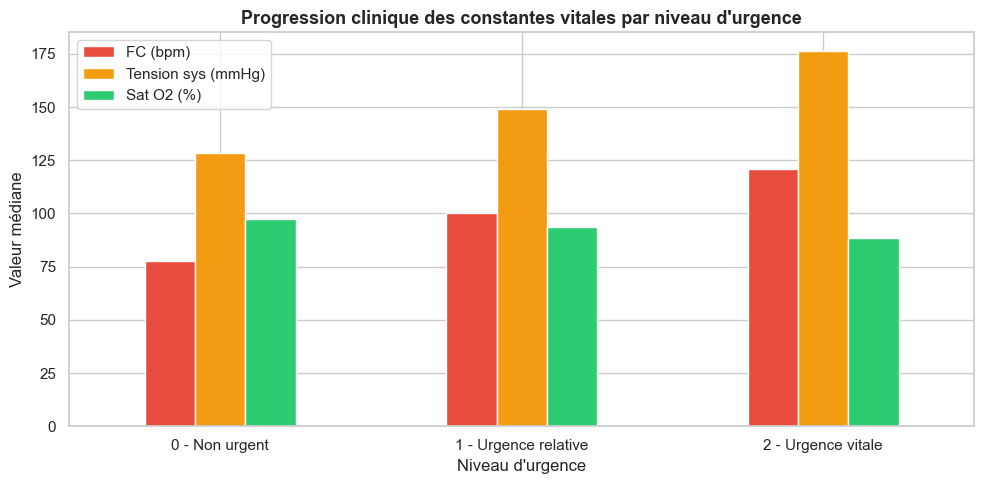

In [28]:
# Médianes des variables numériques par classe
medians_by_class = df.groupby('niveau_urgence')[
    ['age', 'freq_cardiaque', 'tension_sys', 'temp', 'sat_oxygene', 'antecedents', 'duree_symptomes']
].median().round(2)

medians_by_class.index = ['0 - Non urgent', '1 - Urgence relative', '2 - Urgence vitale']
print(" Médianes par classe d'urgence :\n")
display(medians_by_class)

print("\n Observation clinique :")
print("   • freq_cardiaque augmente avec la gravité (77.8 → 100.3 → 120.7 bpm)")
print("   • tension_sys augmente avec la gravité (128.3 → 149.2 → 176.3 mmHg)")
print("   • sat_oxygene diminue avec la gravité (97.5% → 93.5% → 88.6%)")
print("   • Ces tendances confirment la cohérence médicale du dataset.")

# Visualisation
fig, ax = plt.subplots(figsize=(10, 5))
medians_by_class[['freq_cardiaque', 'tension_sys', 'sat_oxygene']].plot(
    kind='bar', ax=ax, color=['#e74c3c', '#f39c12', '#2ecc71'], edgecolor='white'
)
ax.set_title("Progression clinique des constantes vitales par niveau d'urgence",
              fontsize=13, fontweight='bold')
ax.set_xlabel("Niveau d'urgence")
ax.set_ylabel("Valeur médiane")
ax.legend(['FC (bpm)', 'Tension sys (mmHg)', 'Sat O2 (%)'])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 14. Variables sensibles : pouvoir discriminant réel

On vérifie ici si `sexe` et `zone_vie` ont un réel impact sur la distribution de la cible. Si l'impact est négligeable, cela conforte le choix de les retirer dans le Scénario 2 (conformité RGPD) sans crainte de perte de performance.

In [29]:
# Répartition de la cible par sexe
print(" Répartition de niveau_urgence par sexe (%) :\n")
ct_sexe = pd.crosstab(df['sexe'], df['niveau_urgence'], normalize='index') * 100
ct_sexe.columns = ['0 - Non urgent', '1 - Urgence relative', '2 - Urgence vitale']
display(ct_sexe.round(2))

print("\n Répartition de niveau_urgence par zone_vie (%) :\n")
ct_zone = pd.crosstab(df['zone_vie'], df['niveau_urgence'], normalize='index') * 100
ct_zone.columns = ['0 - Non urgent', '1 - Urgence relative', '2 - Urgence vitale']
display(ct_zone.round(2))

# Écart max entre groupes
ecart_sexe = (ct_sexe.max() - ct_sexe.min()).max()
ecart_zone = (ct_zone.max() - ct_zone.min()).max()

print(f"\n Conclusion :")
print(f"   • Écart maximal entre sexes : {ecart_sexe:.2f} points de pourcentage")
print(f"   • Écart maximal entre zones : {ecart_zone:.2f} points de pourcentage")
print(f"   • Ces écarts sont négligeables → sexe et zone_vie n'ont quasiment")
print(f"     aucun pouvoir discriminant sur la cible.")
print(f"   • Cela justifie pleinement leur retrait dans le Scénario 2 (RGPD)")
print(f"     sans risque de perte de performance significative.")

 Répartition de niveau_urgence par sexe (%) :



,0 - Non urgent,1 - Urgence relative,2 - Urgence vitale
sexe,,,
F,50.67,34.59,14.75
H,49.55,35.93,14.52



 Répartition de niveau_urgence par zone_vie (%) :



,0 - Non urgent,1 - Urgence relative,2 - Urgence vitale
zone_vie,,,
R,50.40,35.19,14.41
U,49.91,35.21,14.88



 Conclusion :
   • Écart maximal entre sexes : 1.34 points de pourcentage
   • Écart maximal entre zones : 0.49 points de pourcentage
   • Ces écarts sont négligeables → sexe et zone_vie n'ont quasiment
     aucun pouvoir discriminant sur la cible.
   • Cela justifie pleinement leur retrait dans le Scénario 2 (RGPD)
     sans risque de perte de performance significative.


## 15. Synthèse EDA

Récapitulatif des observations clés et des actions à entreprendre pour la phase de prétraitement.

In [30]:
# 15 synthèse EDA
print("=" * 60)
print("SYNTHÈSE EDA — OBSERVATIONS CLÉS")
print("=" * 60)

print(f"""
 DATASET
   • {df.shape[0]} échantillons × {df.shape[1]} colonnes
   • Aucun NaN sur la variable cible ✅

 DÉSÉQUILIBRE DE CLASSES
   • Classe 0 (Non urgent)       : {(df['niveau_urgence']==0).sum()} ({(df['niveau_urgence']==0).mean()*100:.1f}%)
   • Classe 1 (Urgence relative) : {(df['niveau_urgence']==1).sum()} ({(df['niveau_urgence']==1).mean()*100:.1f}%)
   • Classe 2 (Urgence vitale)   : {(df['niveau_urgence']==2).sum()} ({(df['niveau_urgence']==2).mean()*100:.1f}%)
   ⚠️  Classe 2 sous-représentée → class_weight obligatoire

 VALEURS MANQUANTES
   • Maximum {df.isnull().sum().max()} NaN sur une colonne ({df.isnull().sum().max()/len(df)*100:.1f}%)
   • Imputation par médiane suffisante

 VARIABLES NUMÉRIQUES
   • freq_cardiaque et sat_oxygene : corrélées avec niveau_urgence
   • Outliers présents mais cohérents cliniquement (ex: FC=190)
   • Pas de valeurs aberrantes à supprimer

 TEXTE
   • Longueur moyenne : {df['text_len'].mean():.0f} caractères
   • Vocabulaire discriminant par classe détecté
   • TF-IDF suffisant comme baseline NLP

  VARIABLES CATÉGORIELLES
   • sexe / zone_vie / source : distribution équilibrée
   • Faible impact discriminant → variables sensibles à surveiller

 ACTIONS POUR LA MODÉLISATION
   • Imputer les NaN (médiane pour numérique, mode pour catégoriel)
   • Encoder : sexe, zone_vie, source → One-Hot
   • Vectoriser : description_symptomes → TF-IDF
   • Gérer le déséquilibre : class_weight='balanced'
   • Métrique prioritaire : Recall classe 2
""")

print("=" * 60)
print("EDA terminé — Prêt pour le preprocessing !")
print("=" * 60)

SYNTHÈSE EDA — OBSERVATIONS CLÉS

 DATASET
   • 10080 échantillons × 15 colonnes
   • Aucun NaN sur la variable cible ✅

 DÉSÉQUILIBRE DE CLASSES
   • Classe 0 (Non urgent)       : 5053 (50.1%)
   • Classe 1 (Urgence relative) : 3551 (35.2%)
   • Classe 2 (Urgence vitale)   : 1476 (14.6%)
   ⚠️  Classe 2 sous-représentée → class_weight obligatoire

 VALEURS MANQUANTES
   • Maximum 25 NaN sur une colonne (0.2%)
   • Imputation par médiane suffisante

 VARIABLES NUMÉRIQUES
   • freq_cardiaque et sat_oxygene : corrélées avec niveau_urgence
   • Outliers présents mais cohérents cliniquement (ex: FC=190)
   • Pas de valeurs aberrantes à supprimer

 TEXTE
   • Longueur moyenne : 59 caractères
   • Vocabulaire discriminant par classe détecté
   • TF-IDF suffisant comme baseline NLP

  VARIABLES CATÉGORIELLES
   • sexe / zone_vie / source : distribution équilibrée
   • Faible impact discriminant → variables sensibles à surveiller

 ACTIONS POUR LA MODÉLISATION
   • Imputer les NaN (médiane pou